(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.1091 - loss: 106.2310 - val_accuracy: 0.3399 - val_loss: 101.4369
loss=101.4368667602539
accuracy=0.3398999869823456
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
(10000, 28, 28)
(10000, 10)


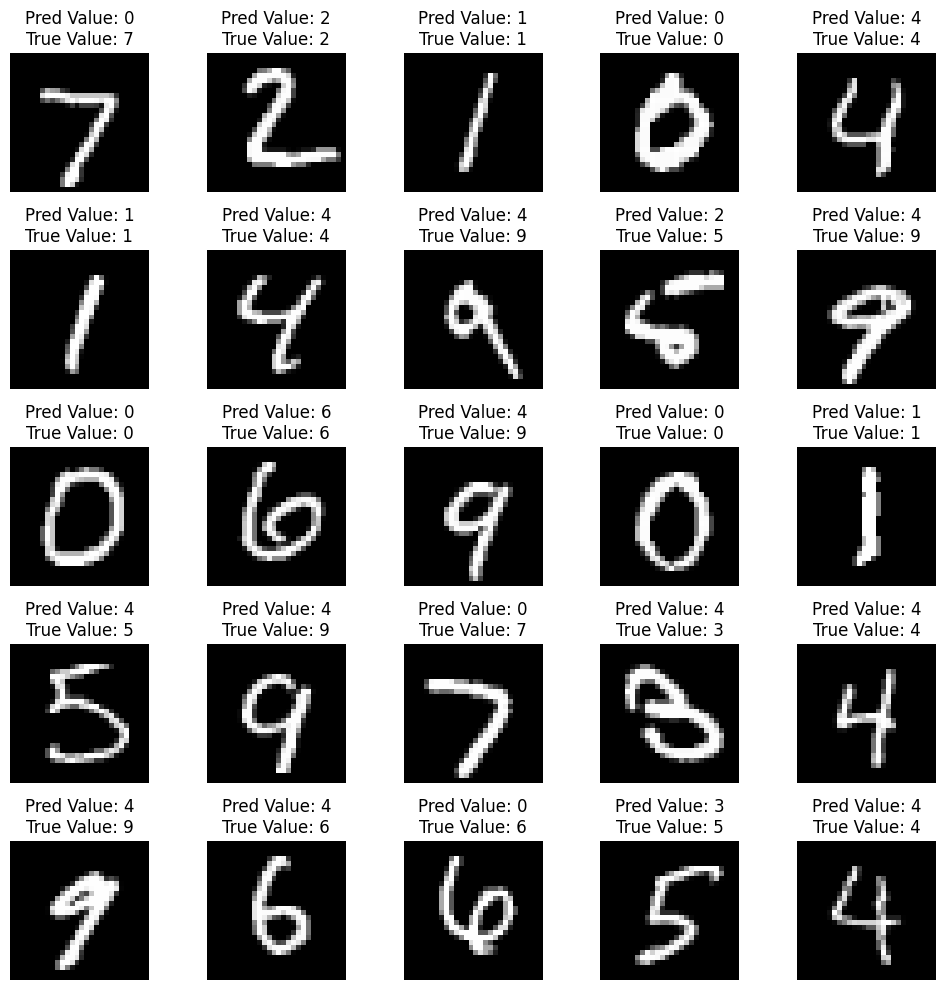

In [5]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten
import matplotlib.pyplot as plt



(trainX,trainY),(testX,testY)=load_data()
print(trainX.shape,trainY.shape)
print(testX.shape,testY.shape)
inputs = Input(shape=(28, 28))
x=Flatten()(inputs)
x1=Dense(512,activation='relu')(x)
x2=Dense(1024,activation='relu')(x1)
x3=Dense(512,activation='relu')(x2)
outputs=Dense(10,activation='softmax')(x3)
model=Model(inputs,outputs)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=model.fit(trainX,trainY,epochs=1,batch_size=32000,validation_data=(testX,testY),verbose=1)

loss,accuracy=model.evaluate(testX,testY,verbose=0)
print(f"loss={loss}")
print(f"accuracy={accuracy}")


import matplotlib.pyplot as plt
import numpy as np

# Get predictions
predY = model.predict(testX)
print(testX.shape)
print(predY.shape)
pred_labels = predY.argmax(axis=1)

# Plot 25 test images with predictions
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(testX[i], cmap='gray')
    plt.title(f"Pred Value: {pred_labels[i]}\nTrue Value: {testY[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
